In [2]:
from py_files.setup import *
setup_notebook()

# %pip install git+https://github.com/alemartinello/dstapi
from IPython.display import display
from io import StringIO
from dstapi import DstApi
from functools import reduce

# `Expenditure shares`

### 1. IPP, equip. and struc.

- **DST table for investment by asset type: NAHI:** Gross capital formation by assets, price unit and time
- **DST table for GDP:** Use NAN1: Demand and supply by transaction and price unit.

In [3]:
# 1. get using DST API
NAHI = DstApi('NAHI')
NAN1 = DstApi('NAN1')
# NAHI.tablesummary(language='en')
# NAHI.variable_levels('AKTIV',language='en')

# 2. set up fetch
params_I = {
    'table': 'NAHI',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V']},     # current prices (m. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'AKTIV', 'values': ['*']}
        ]
}
params_Y = {
    'table': 'NAN1',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V_M']},   # current prices (b. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'TRANSAKT', 'values': ['B1GQK']}
        ]
}

# 3. get data
df_I = NAHI.get_data(params=params_I)
df_Y = NAN1.get_data(params=params_Y)
df_I['INDHOLD'] = pd.to_numeric(df_I['INDHOLD'], errors='coerce')
df_Y['INDHOLD'] = pd.to_numeric(df_Y['INDHOLD'], errors='coerce')

# 4. helper to sum a set of AKTIV each year
def sum_aktiv(df, aktiv_list, colname):
    return (df.loc[df['AKTIV'].isin(aktiv_list), ['TID','INDHOLD']]
              .groupby('TID', as_index=False)['INDHOLD'].sum()
              .rename(columns={'INDHOLD': colname}))

struc_list = ['Dwellings','Buildings other than dwellings','Other structures and land improvements']
equip_list = ['ICT equipment, other machinery and equipment and weapon systems','Transport equipment']
IPP_list   = ['Intellectual property products']

# 5. investment aggregates by year
I_struc = sum_aktiv(df_I, struc_list, 'I_struc')
I_equip = sum_aktiv(df_I, equip_list, 'I_equip')
I_ipp   = sum_aktiv(df_I, IPP_list,   'I_ipp')

GDP = (df_Y.loc[df_Y['TRANSAKT'].eq('B.1*g Gross domestic product'), ['TID','INDHOLD']]
         .groupby('TID', as_index=False)['INDHOLD'].sum()
         .rename(columns={'INDHOLD': 'GDP'}))
GDP['GDP_cp'] = GDP.GDP * 1e3 # convert from b. DKK to m. DKK

# 7. merge + compute shares
df = reduce(lambda left, right: pd.merge(left, right, on='TID', how='inner'),
            [GDP, I_struc, I_equip, I_ipp])

for c in ['I_struc','I_equip','I_ipp']:
    df[c + '_share'] = df[c] / df['GDP_cp']       # level share
    df[c + '_pct']   = 100 * df[c + '_share']     # percent

df = df.sort_values('TID').reset_index(drop=True)
out = df[['TID','GDP_cp','I_struc_pct','I_equip_pct','I_ipp_pct']]

# 8. print
print('\nOverview of movements over time (1): ==============')
print(f'IPP:       start value: {out.iloc[0].I_ipp_pct/100:.2%},  end value : {out.iloc[-1].I_ipp_pct/100:.2%}')
print(f'Equipment: start value: {out.iloc[0].I_equip_pct/100:.2%},  end value : {out.iloc[-1].I_equip_pct/100:.2%}')
print(f'Structure: start value: {out.iloc[0].I_struc_pct/100:.2%}, end value : {out.iloc[-1].I_struc_pct/100:.2%}')


Overview of movements over time (1): ==============
IPP:       start value: 0.98%,  end value : 7.03%
Equipment: start value: 7.94%,  end value : 5.61%
Structure: start value: 15.65%, end value : 10.70%


### 2. organisational services

**Uses:** NAIO1F and adds the fourth category to the investment expenditures.
1. **Type:** Domestic produciton.
2. **Supplying industries:**
    - Management of companies and enterprises:
        - 69700 Legal and accounting activities; activities of head offices; management consultancy
    - Administrative and support services”:
        - 78000 Employment activities
        - 80820 Security and investigation; services to buildings and landscape; other business services
        - (potentielly): 77000 Rental and leasing actiities
    - Miscellaneous professional, scientific, and technical services:
        - 74750 Other professional, scientific and technical activities; veterinary activities
        - (potentially): 71000 Architectural and engineering activities
3. **Getting industries:** Intermediate consumption by industries
4. **Use:** Intermediate use.

In [4]:
NAIO1F = DstApi('NAIO1F')
# NAIO1F.tablesummary(language='en')
# NAIO1F.variable_levels('TILGANG2',language='en')
# NAIO1F.variable_levels('ANVENDELSE',language='en')

In [5]:
supply = [
    # Core organizational services (your current selection)
    'T69700',  # Legal/accounting/head offices/management consultancy - matches "Management of companies" + "Legal services"
    'T78000',  # Employment activities - matches "Administrative and support"
    'T80820',  # Security/cleaning/other business services - matches "Administrative and support"
    'T74750',  # Other professional/scientific/technical - matches "Misc professional scientific"
    'T71000',  # Architectural and engineering - matches "Misc professional scientific"
    
    # Additions to expand coverage
    'T77000',  # Rental and leasing activities - part of admin support in BEA
    'T73000',  # Advertising and market research - part of misc professional in BEA
    'T62630',  # IT and information service activities - matches "Computer systems design"
    'T79000',  # Travel agent activities - part of admin support in BEA
    'T62630',  # (IT services)
]

In [6]:
# Use (column)
use = ['AI00000'] 

params_io = {
    'table' : 'NAIO1F',
    'format': 'BULK',
    'lang'  : 'en',
    'variables': [
        {'code': 'PRISENHED'    , 'values': ['V']},       
        {'code': 'Tid'          , 'values': ['*']},
        {'code': 'TILGANG1'     , 'values': ['P1_BP']},   
        {'code': 'TILGANG2'     , 'values': supply},      # FROM these industries
        {'code': 'ANVENDELSE'   , 'values': ['AI00000']}, # TO total intermediate use
    ]
}

io_ = NAIO1F.get_data(params=params_io)
io_['INDHOLD'] = pd.to_numeric(io_['INDHOLD'], errors='coerce')

# 2. aggregate
io_["orga_ser"] = io_.groupby("TID")["INDHOLD"].transform("sum")
io = io_[['TID','orga_ser']].drop_duplicates().reset_index(drop=True)

# 3. inly include fraction of these 
kappa = 0.6
io['orga_ser'] = io['orga_ser'] * kappa

# 3. find shares
io['orga_ser_pct'] = (io['orga_ser'] / df['GDP_cp']) *100

print('\nOverview of movements over time (2): ===========================')
print(f'Organisational services: start value: {io.iloc[0].orga_ser_pct/100:.2%},  end value : {io.iloc[-1].orga_ser_pct/100:.2%}')


Overview of movements over time (2): ===========================
Organisational services: start value: 2.36%,  end value : 7.91%


*plot a la figure 5* 

/var/folders/t6/3c29w60n57n_vr9ftbb88pdr0000gn/T/ipykernel_4330/1369069255.py:40: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 4
  ax.legend(handles=polys, labels=labels, frameon=True, loc="upper left")


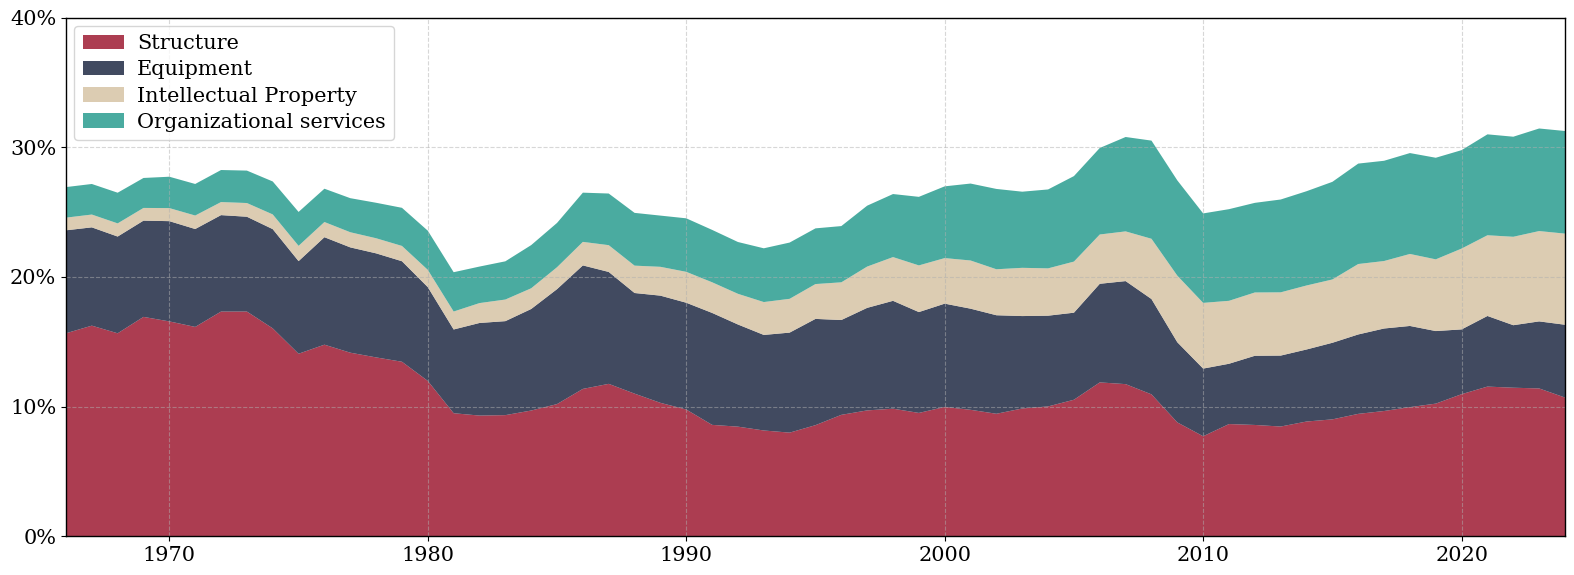


Overview of movements over time (3): ===========================
Total intangibles:       start value: 3.33%,  end value : 14.94%
Total classic assets:    start value: 23.59%, end value : 16.31%


In [7]:
x = out["TID"].to_numpy()

# 1. bottom to top order
labels = ["Structure", "Equipment", "Intellectual Property", "Organizational services"]
ys = np.vstack([
    out["I_struc_pct"].to_numpy(),
    out["I_equip_pct"].to_numpy(),
    out["I_ipp_pct"].to_numpy(),
    io["orga_ser_pct"].to_numpy(),
    out.get("I_org_pct", pd.Series(0.0, index=out.index)).to_numpy(),
])

# 2. plot
colors = [
    "#9E1B32",  # crimson (anchor)
    "#1F2A44",  # deep navy
    "#D6C3A5",  # warm sand
    "#2A9D8F",  # teal
]

fig, ax = plt.subplots(figsize=(16, 6))

polys = ax.stackplot(
    x, ys,
    colors=colors,
    linewidth=0.8,
    # edgecolor="0.4",
    alpha=0.85,
)

ax.set_ylim(0, np.nanmax(np.sum(ys, axis=0)) * 1.05)
ax.set_yticks([0, 10, 20, 30, 40])
ax.set_yticklabels([f"{t:.0f}%" for t in [0, 10, 20, 30, 40]])

ax.set_xlim(x.min(), x.max())
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

ax.legend(handles=polys, labels=labels, frameon=True, loc="upper left")

plt.tight_layout()
plt.show()

print('\nOverview of movements over time (3): ===========================')
intan_s = out.iloc[0]["I_ipp_pct"] +io.iloc[0]['orga_ser_pct']
intan_e = out.iloc[-1]["I_ipp_pct"] + io.iloc[-1]['orga_ser_pct']

classic_s = out.iloc[0]["I_struc_pct"] + out.iloc[0]["I_equip_pct"]
classic_e = out.iloc[-1]["I_struc_pct"] + out.iloc[-1]["I_equip_pct"]

print(f'Total intangibles:       start value: {intan_s/100:.2%},  end value : {intan_e/100:.2%}')
print(f'Total classic assets:    start value: {classic_s/100:.2%}, end value : {classic_e/100:.2%}')

# `Labour share`

**Use:** 
1. NABP69 for `Compensation of employees`.
2. RAS310 for `educational decomposition`.

**Structure:**
1. Get IO matrix A (industry × industry intermediate flows)
2. Compute Leontief inverse $L = (I - A)^{-1}$
3. Get direct labor share by industry (labor comp / gross output)
4. Compute consolidated labor share = L' × direct_labor_share
5. Get final use by industry (C and I columns)
6. Rank by contribution to C and I, plot top 20